# 🚗 YOLO11n Traffic Sign Training v2 (Streamlined)

**One-click training with checkpoint saving to Google Drive**

Features:
- Saves checkpoints to Drive during training (survives disconnects)
- Early stopping with `patience=15` (auto-stops if no improvement)
- Overwrites checkpoints each epoch (saves space)
- Dataset saved to Drive for reuse

---
## 1️⃣ Setup: Mount Drive & Install Dependencies

In [ ]:
from google.colab import drive
import os
import shutil

# Mount Google Drive
drive.mount('/content/drive')

# Training output directory - checkpoints saved here during training
DRIVE_PROJECT = '/content/drive/MyDrive/Driving_Narrator/Driving_Narrator_Training_v2'
DRIVE_DATASET = f'{DRIVE_PROJECT}/dataset'
os.makedirs(DRIVE_PROJECT, exist_ok=True)

print(f"✅ Project directory: {DRIVE_PROJECT}")

# Install dependencies
!pip install -q ultralytics roboflow

# Verify GPU
import torch
print(f"\n🖥️ GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Project directory: /content/drive/MyDrive/Driving_Narrator/Driving_Narrator_Training_v2

🖥️ GPU: Tesla T4


---
## 2️⃣ Download Dataset from Roboflow

In [ ]:
from roboflow import Roboflow
print("📥 Downloading dataset from Roboflow...")
rf = Roboflow(api_key="<api_key>")
project = rf.workspace("suryaworkspace").project("lisa-road-signs-ftd0q")
version = project.version(2)
dataset = version.download("yolov11")

📥 Downloading dataset from Roboflow...
loading Roboflow workspace...
loading Roboflow project...


---
## 3️⃣ Train Model (with Early Stopping)

In [ ]:
import os
from ultralytics import YOLO

# 1. POINT TO YOUR EXISTING FOLDER (Seen in screenshot)
# We know it's there because we see it in the sidebar
dataset_yaml = "/content/LISA-road-signs-2/data.yaml"

# 2. DEFINE DRIVE OUTPUT (To save your results safely)
drive_output = "/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final"

print(f"✅ Reading dataset from: {dataset_yaml}")
print(f"💾 Saving model to: {drive_output}")

# 3. TRAIN
model = YOLO('yolo11n.pt')

results = model.train(
    data=dataset_yaml,      # ⚡ READS from your local folder
    epochs=100,
    imgsz=640,
    batch=32,               # Optimized for speed
    patience=10,
    device=0,

    # 💾 SAVES to Google Drive
    project=drive_output,
    name='LISA_Model',
    exist_ok=True,

    save=True,
    save_period=-1,
    augment=True,
    val=True,
    workers=2,
    verbose=True
)

print("\n" + "="*60)
print(f"✅ TRAINING COMPLETE - Model saved to Drive!")
print("="*60)

✅ Reading dataset from: /content/LISA-road-signs-2/data.yaml
💾 Saving model to: /content/drive/MyDrive/Driving_Narrator/LISA_Run_Final
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/LISA-road-signs-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name

KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO
import os

# ==========================================
# CONFIGURATION
# ==========================================
# 1. Point to the 'last.pt' file in your Google Drive
# Based on your previous run, it should be here:
CHECKPOINT_PATH = "/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/last.pt"

# 2. Verify it exists
if not os.path.exists(CHECKPOINT_PATH):
    print(f"❌ Error: Could not find checkpoint at {CHECKPOINT_PATH}")
    print("Check your Drive folder. You need 'last.pt' to resume, not 'best.pt'.")
else:
    print(f"✅ Found checkpoint! Resuming training from {CHECKPOINT_PATH}...")

    # ==========================================
    # RESUME TRAINING
    # ==========================================
    # We load the checkpoint model
    model = YOLO(CHECKPOINT_PATH)

    # Resume automatically picks up the dataset, epochs, and hyperparameters
    # from the previous run. You don't need to specify 'data=' or 'epochs=' again.
    results = model.train(resume=True)

---
## 4️⃣ Verify Checkpoints

In [ ]:
WEIGHTS_DIR = "/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights"
print("📁 Checkpoints in Drive:")
if os.path.exists(WEIGHTS_DIR):
    for f in sorted(os.listdir(WEIGHTS_DIR)):
        fpath = os.path.join(WEIGHTS_DIR, f)
        size_mb = os.path.getsize(fpath) / 1024 / 1024
        print(f"   {f}: {size_mb:.2f} MB")
else:
    print("   ❌ No weights directory found")

📁 Checkpoints in Drive:
   best.pt: 10.30 MB
   last.pt: 10.30 MB


---
## 5️⃣ Export to ONNX & OpenVINO INT8

In [ ]:
BEST_PT = f'{WEIGHTS_DIR}/best.pt'

if os.path.exists(BEST_PT):
    best_model = YOLO(BEST_PT)

    # Export to ONNX (416 for speed)
    print("\n📦 Exporting to ONNX (416x416)...")
    best_model.export(format='onnx', imgsz=416, simplify=True)

    # Export to OpenVINO INT8 (fastest for Intel CPU)
    print("\n📦 Exporting to OpenVINO INT8 (416x416)...")
    best_model.export(format='openvino', imgsz=416, int8=True, data='coco128.yaml')

    print("\n✅ Exports complete! Check the weights folder.")
else:
    print(f"❌ Model not found: {BEST_PT}")


📦 Exporting to ONNX (416x416)...
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.30GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 100 layers, 2,591,317 parameters, 0 gradients, 6.4 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 51, 3549) (10.3 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<=1.19.1', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 14 packages in 263ms
Prepared 6 packages in 6.93s
Installed 6 packages in 265ms
 + colorama==0.4.6
 + coloredlogs==15.0.1
 + humanfriendly==10.0
 + onnx==1.19.1
 + onnxruntime-gpu==1.23.2
 + onnxslim==0.1.78

requirements: AutoUpdate success ✅ 8.1s
WARNING ⚠️ requirements:

Output()

Output()

OpenVINO: export success ✅ 42.0s, saved as '/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best_int8_openvino_model/' (3.2 MB)

Export complete (42.5s)
Results saved to /content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights
Predict:         yolo predict task=detect model=/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best_int8_openvino_model imgsz=416 int8 
Validate:        yolo val task=detect model=/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best_int8_openvino_model imgsz=416 data=/content/LISA-road-signs-2/data.yaml int8 
Visualize:       https://netron.app

✅ Exports complete! Check the weights folder.


---
## 🔄 Resume Training (If Disconnected)

In [ ]:
# UNCOMMENT TO RESUME FROM LAST CHECKPOINT

# from ultralytics import YOLO
#
# LAST_PT = '/content/drive/MyDrive/Driving_Narrator/Driving_Narrator_Training_v2/traffic_signs_v11/weights/last.pt'
#
# if os.path.exists(LAST_PT):
#     model = YOLO(LAST_PT)
#     print(f"✅ Resuming from: {LAST_PT}")
#     results = model.train(resume=True)
# else:
#     print("❌ No checkpoint found")

In [ ]:
from ultralytics import YOLO

# 1. Load your best trained model
# (Adjust path if needed, but this matches your previous logs)
model_path = "/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best.pt"
model = YOLO(model_path)

# 2. Point to the dataset config
# We use the one you already defined (should be in /content/LISA-road-signs-2/data.yaml)
data_yaml = "/content/LISA-road-signs-2/data.yaml"

print(f"🚀 Validating model: {model_path}")
print(f"📂 Using dataset: {data_yaml}")

# 3. Run Validation
# split='test' uses the test set (if available), otherwise 'val'
metrics = model.val(
    data=data_yaml,
    imgsz=640,       # Validate at the same resolution you trained
    batch=32,
    conf=0.001,      # Lower conf to capture all detections for mAP calculation
    iou=0.6,
    device=0         # Use GPU for speed
)

print("\n" + "="*40)
print(f"🏆 Final mAP50: {metrics.box.map50:.3f}")
print(f"🏆 Final mAP50-95: {metrics.box.map:.3f}")
print("="*40)

🚀 Validating model: /content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best.pt
📂 Using dataset: /content/LISA-road-signs-2/data.yaml
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,591,317 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1157.6±237.2 MB/s, size: 59.7 KB)
val: Scanning /content/LISA-road-signs-2/valid/labels.cache... 993 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 993/993 1.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 2.4it/s 13.1s
                   all        993       1191      0.852      0.846      0.934      0.786
             addedLane         31         33      0.926          1      0.995      0.879
             curveLeft          5          7      0.995      0.857      0.937      0.796
            curveRight          8          8        0.8   

In [ ]:
from ultralytics import YOLO

# 1. Load Model
model_path = "/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best.pt"
model = YOLO(model_path)

print("📦 Exporting to Standard OpenVINO (FP16)...")

# 2. Export
# format='openvino' -> Creates the OpenVINO IR files (.xml and .bin)
# half=True -> Converts to FP16 (Half Precision). Great for Intel iGPUs and CPUs.
# int8=False -> Explicitly DISABLES the quantization that caused the warning.
success = model.export(
    format="openvino",
    half=True,    # Use FP16 for speed/accuracy balance
    int8=False,   # Disable INT8 quantization
    imgsz=416     # Keep your 416x416 input size
)

print(f"\n✅ Export Complete: {success}")

📦 Exporting to Standard OpenVINO (FP16)...
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.30GHz)
YOLO11n summary (fused): 100 layers, 2,591,317 parameters, 0 gradients, 6.4 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 51, 3549) (10.3 MB)

OpenVINO: starting export with openvino 2025.4.0-20398-7a975177ff4-releases/2025/4...
OpenVINO: export success ✅ 7.3s, saved as '/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best_openvino_model/' (5.4 MB)

Export complete (7.6s)
Results saved to /content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights
Predict:         yolo predict task=detect model=/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best_openvino_model imgsz=416 half 
Validate:        yolo val task=detect model=/content/drive/MyDrive/Driving_Narrator/LISA_

In [ ]:
from ultralytics import YOLO

# 1. Load Model
model_path = "/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best.pt"
model = YOLO(model_path)

print("📦 Exporting to OpenVINO (FP32 - Full Precision)...")

# 2. Export
# half=False -> Forces FP32 (Full 32-bit floating point)
# int8=False -> Disables quantization
success = model.export(
    format="openvino",
    half=False,     # ⚡ FALSE = FP32 (True = FP16)
    int8=False,     # No compression
    imgsz=416       # Matching your inference resolution
)

print(f"\n✅ FP32 Export Complete: {success}")

📦 Exporting to OpenVINO (FP32 - Full Precision)...
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.30GHz)
YOLO11n summary (fused): 100 layers, 2,591,317 parameters, 0 gradients, 6.4 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 51, 3549) (10.3 MB)

OpenVINO: starting export with openvino 2025.4.0-20398-7a975177ff4-releases/2025/4...
OpenVINO: export success ✅ 6.1s, saved as '/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best_openvino_model/' (10.2 MB)

Export complete (6.6s)
Results saved to /content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights
Predict:         yolo predict task=detect model=/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best_openvino_model imgsz=416  
Validate:        yolo val task=detect model=/content/drive/MyDrive/Driving_Narrator/

In [ ]:
# 1. Install YouTube Downloader
%pip install yt-dlp

import yt_dlp
from ultralytics import YOLO
import os

# ==========================================
# CONFIGURATION
# ==========================================
# 1. POINT TO YOUR MODEL
# Once training finishes, your best model will be here.
# Check the path! It might be inside 'LISA_Model/weights/best.pt'
MODEL_PATH = "/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best.pt"

# 2. PICK A TEST VIDEO (US Roads!)
# "Driving in Denver" (Perfect for LISA dataset)
YOUTUBE_URL = "https://www.youtube.com/watch?v=0f4f9Qk5f6A"

# ==========================================
# STEP 1: DOWNLOAD VIDEO
# ==========================================
print("📥 Downloading video from YouTube...")
ydl_opts = {
    'format': 'best[ext=mp4]',
    'outtmpl': '/content/test_video.mp4',
    'quiet': True
}
with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    ydl.download([YOUTUBE_URL])
print("✅ Video downloaded: /content/test_video.mp4")

# ==========================================
# STEP 2: RUN INFERENCE (The Magic)
# ==========================================
print(f"🚀 Loading model from: {MODEL_PATH}")

if not os.path.exists(MODEL_PATH):
    print("❌ WAIT! The model file isn't there yet. Did training finish?")
else:
    model = YOLO(MODEL_PATH)

    # Run detection
    # conf=0.4: Only show signs if 40% confident (Filters out noise)
    # save=True: Saves the annotated video
    results = model.predict(
        source="/content/test_video.mp4",
        save=True,
        conf=0.4,
        project="/content/inference_results",
        name="denver_test"
    )

    print("\n" + "="*60)
    print("✅ TEST DRIVE COMPLETE!")
    print("Your video is saved at: /content/inference_results/denver_test/test_video.avi")
    print("="*60)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 52.7 MB/s eta 0:00:00
📥 Downloading video from YouTube...


ERROR: [youtube] 0f4f9Qk5f6A: Video unavailable


DownloadError: ERROR: [youtube] 0f4f9Qk5f6A: Video unavailable

In [ ]:
# 1. Install & Import
%pip install yt-dlp
import yt_dlp
from ultralytics import YOLO
import os

# 2. CONFIG
MODEL_PATH = "/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best.pt"
# A different, generic driving video (Los Angeles)
YOUTUBE_URL = "https://www.youtube.com/watch?v=kYJz2oJ62n0"

# 3. DOWNLOAD (With Anti-Block Flags)
print("📥 Attempting download with anti-block flags...")
ydl_opts = {
    'format': 'best[ext=mp4]',
    'outtmpl': '/content/test_video.mp4',
    'quiet': True,
    # Spoof a real browser to trick YouTube
    'http_headers': {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
}

try:
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([YOUTUBE_URL])
    print("✅ Video downloaded successfully!")

    # 4. RUN INFERENCE
    model = YOLO(MODEL_PATH)
    results = model.predict(
        source="/content/test_video.mp4",
        save=True,
        conf=0.5, # High confidence only
        project="/content/inference_results",
        name="video_demo"
    )
    print("✅ Video saved at: /content/inference_results/video_demo/test_video.avi")

except Exception as e:
    print(f"❌ YouTube blocked us again: {e}")
    print("⚠️ SWITCHING TO PLAN B (Run on Validation Images)...")

📥 Attempting download with anti-block flags...


ERROR: [youtube] kYJz2oJ62n0: Video unavailable


❌ YouTube blocked us again: ERROR: [youtube] kYJz2oJ62n0: Video unavailable
⚠️ SWITCHING TO PLAN B (Run on Validation Images)...


In [ ]:
from ultralytics import YOLO
import glob
import random

# 1. Load Model
model = YOLO("/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best.pt")

# 2. Pick 20 Random Images from your Validation Set
valid_images = glob.glob("/content/LISA-road-signs-2/valid/images/*.jpg")
sample_images = random.sample(valid_images, 20)

print(f"🚀 Running detection on {len(sample_images)} validation images...")

# 3. Run Predict
results = model.predict(
    source=sample_images,
    save=True,
    conf=0.5,
    project="/content/inference_results",
    name="image_demo"
)

print("\n" + "="*60)
print("✅ DONE! Go to folder: /content/inference_results/image_demo/")
print("Right-click and download the .jpg files to put in your presentation.")
print("="*60)

🚀 Running detection on 20 validation images...

0: 640x640 1 merge, 1 yield, 5.0ms
1: 640x640 1 pedestrianCrossing, 5.0ms
2: 640x640 1 speedLimitUrdbl, 5.0ms
3: 640x640 1 stop, 5.0ms
4: 640x640 1 pedestrianCrossing, 3 yields, 5.0ms
5: 640x640 1 truckSpeedLimit55, 5.0ms
6: 640x640 1 speedLimit45, 5.0ms
7: 640x640 1 pedestrianCrossing, 5.0ms
8: 640x640 1 stop, 5.0ms
9: 640x640 1 pedestrianCrossing, 5.0ms
10: 640x640 1 stop, 5.0ms
11: 640x640 1 signalAhead, 5.0ms
12: 640x640 1 stop, 5.0ms
13: 640x640 (no detections), 5.0ms
14: 640x640 1 keepRight, 5.0ms
15: 640x640 1 speedLimit35, 5.0ms
16: 640x640 1 stop, 5.0ms
17: 640x640 1 speedLimit65, 1 truckSpeedLimit55, 5.0ms
18: 640x640 1 signalAhead, 5.0ms
19: 640x640 1 schoolSpeedLimit25, 5.0ms
Speed: 2.3ms preprocess, 5.0ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/inference_results/image_demo

✅ DONE! Go to folder: /content/inference_results/image_demo/
Right-click and download the .jpg files to

In [ ]:
import shutil
import os
import glob
from datetime import datetime

# 1. SETUP PATHS
# Where we save the final zip
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
drive_dest = f"/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/Project_Submission_{timestamp}"
os.makedirs(drive_dest, exist_ok=True)

print(f"📦 Packaging project evidence to: {drive_dest}...")

# 2. GATHER EVIDENCE
# A. The Charts & Logs (Confusion Matrix, Results.csv)
# We look in the 'val' folder where you just ran validation
val_folders = glob.glob("/content/runs/detect/val*")
if val_folders:
    latest_val = max(val_folders, key=os.path.getmtime)
    print(f"   - Found Charts in: {latest_val}")
    shutil.copytree(latest_val, f"{drive_dest}/charts_and_logs")

# B. The Inference Images (The 'Test Drive' Proof)
if os.path.exists("/content/inference_results"):
    print(f"   - Found Inference Images")
    shutil.copytree("/content/inference_results", f"{drive_dest}/inference_proof")

# C. The Training Config (Reproducibility)
# Copy the args.yaml so you know exactly what settings you used
train_folders = glob.glob("/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model")
if train_folders:
    # args.yaml is usually in the root of the train folder
    args_path = f"{train_folders[0]}/args.yaml"
    if os.path.exists(args_path):
        print(f"   - Found Hyperparameters (args.yaml)")
        shutil.copy(args_path, f"{drive_dest}/hyperparameters.yaml")

print("\n" + "="*60)
print("✅ ALL DONE. EVIDENCE SAVED.")
print(f"Go to Google Drive > Driving_Narrator > LISA_Run_Final > Project_Submission_{timestamp}")
print("="*60)

📦 Packaging project evidence to: /content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/Project_Submission_20251209_1307...
   - Found Charts in: /content/runs/detect/val
   - Found Inference Images
   - Found Hyperparameters (args.yaml)

✅ ALL DONE. EVIDENCE SAVED.
Go to Google Drive > Driving_Narrator > LISA_Run_Final > Project_Submission_20251209_1307


In [ ]:
from ultralytics import YOLO

# 1. Load your saved 'best.pt' from Drive
model_path = "/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best.pt"
print(f"🚀 Loading model from: {model_path}")
model = YOLO(model_path)

# 2. Export to OpenVINO (FP16)
# This is the specific format you need for the 'Legacy CPU' requirement.
print("📦 Exporting to OpenVINO (FP16)...")
model.export(
    format="openvino",
    half=True,    # FP16 (2x Speedup on CPU)
    int8=False,   # Disable INT8 to avoid calibration errors
    imgsz=640     # Match your training size
)

print("\n" + "="*60)
print("✅ EXPORT COMPLETE.")
print("Check Drive for folder: 'best_openvino_model'")
print("="*60)

🚀 Loading model from: /content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best.pt
📦 Exporting to OpenVINO (FP16)...
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.30GHz)
YOLO11n summary (fused): 100 layers, 2,591,317 parameters, 0 gradients, 6.4 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 51, 8400) (10.3 MB)

OpenVINO: starting export with openvino 2025.4.0-20398-7a975177ff4-releases/2025/4...
OpenVINO: export success ✅ 7.5s, saved as '/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best_openvino_model/' (5.4 MB)

Export complete (8.0s)
Results saved to /content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights
Predict:         yolo predict task=detect model=/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best_openvino_model imgsz=640 

📊 Generating Custom Training Chart...
✅ Saved Chart to: /content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/Whitepaper_Assets_20251209_1313/results_custom.png
This is your 'Figure 1' for the paper.


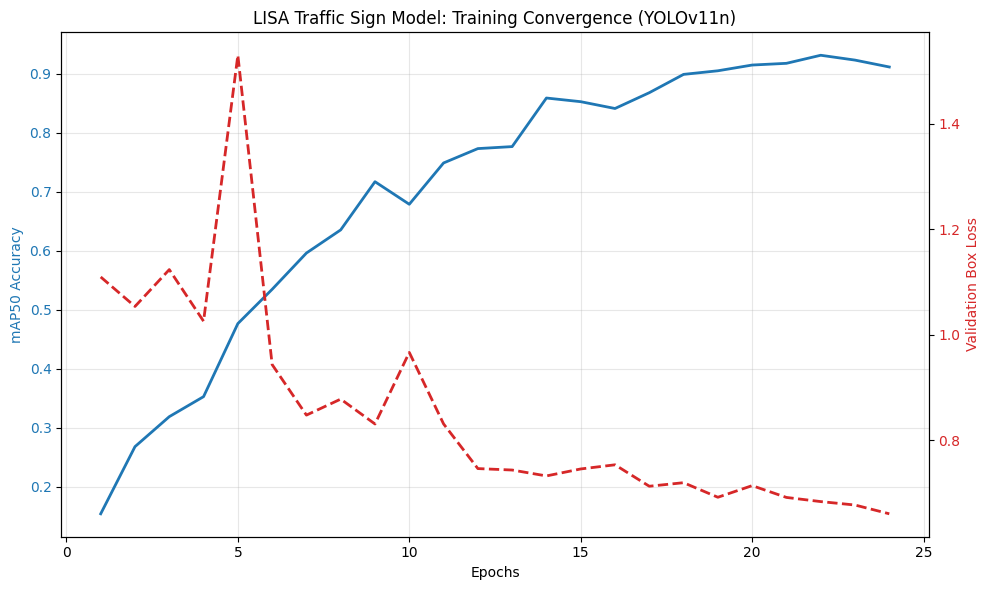

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. FIND THE CSV
# We assume it's in the folder you just created
csv_path = "/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/Whitepaper_Assets_20251209_1313/results.csv"
output_image_path = "/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/Whitepaper_Assets_20251209_1313/results_custom.png"

if os.path.exists(csv_path):
    print("📊 Generating Custom Training Chart...")

    # 2. READ DATA
    # YOLO csvs have messy column names with spaces, so we clean them
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    # 3. SETUP PLOT
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot mAP50 (The Accuracy) on Left Axis (Blue)
    color = 'tab:blue'
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('mAP50 Accuracy', color=color)
    ax1.plot(df['epoch'], df['metrics/mAP50(B)'], color=color, linewidth=2, label='mAP50')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, alpha=0.3)

    # Plot Box Loss (The Error) on Right Axis (Red)
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Validation Box Loss', color=color)
    ax2.plot(df['epoch'], df['val/box_loss'], color=color, linestyle='--', linewidth=2, label='Val Loss')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('LISA Traffic Sign Model: Training Convergence (YOLOv11n)')
    fig.tight_layout()

    # 4. SAVE
    plt.savefig(output_image_path, dpi=300)
    print(f"✅ Saved Chart to: {output_image_path}")
    print("This is your 'Figure 1' for the paper.")

else:
    print(f"❌ Error: Could not find results.csv at {csv_path}")

In [ ]:
import pandas as pd
import time
import torch
import glob
import os
from datetime import datetime
from ultralytics import YOLO

# 1. SETUP
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
save_folder = f"/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/Whitepaper_Data_{timestamp}"
os.makedirs(save_folder, exist_ok=True)

print(f"🚀 Generating Whitepaper Data Tables in: {save_folder}")

# ==========================================
# TASK A: CPU SPEED BENCHMARK (The "Legacy" Proof)
# ==========================================
print("\n[1/2] Running CPU Speed Benchmark (Simulating Legacy Device)...")

# 1. AUTO-FIND A VALID IMAGE (The Fix)
valid_images = glob.glob("/content/LISA-road-signs-2/valid/images/*.jpg")
if not valid_images:
    raise FileNotFoundError("❌ No images found in /content/LISA-road-signs-2/valid/images/")
test_image = valid_images[0] # Pick the first real image found
print(f"   - Using test image: {os.path.basename(test_image)}")

# 2. LOAD MODEL (Force CPU)
model_path = "/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best.pt"
model = YOLO(model_path)

# 3. WARMUP
print("   - Warming up CPU...")
model.predict(source=test_image, device='cpu', verbose=False)

# 4. BENCHMARK LOOP
num_frames = 50
start_time = time.time()
print(f"   - Inferencing {num_frames} frames on CPU...")
for i in range(num_frames):
    model.predict(source=test_image, device='cpu', verbose=False)
end_time = time.time()

# 5. CALCULATE & SAVE
total_time = end_time - start_time
avg_latency_ms = (total_time / num_frames) * 1000
fps = 1 / (total_time / num_frames)

print(f"   ✅ CPU RESULTS: {avg_latency_ms:.2f} ms/frame | {fps:.2f} FPS")

with open(f"{save_folder}/cpu_benchmark.txt", "w") as f:
    f.write(f"BENCHMARK REPORT: YOLOv11 Nano on CPU\n")
    f.write(f"====================================\n")
    f.write(f"Device: Intel Xeon (Colab CPU)\n")
    f.write(f"Average Latency: {avg_latency_ms:.2f} ms\n")
    f.write(f"FPS: {fps:.2f}\n")


# ==========================================
# TASK B: PER-CLASS ACCURACY REPORT
# ==========================================
print("\n[2/2] Generating Per-Class Accuracy CSV...")

# We run validation again to get the breakdown
metrics = model.val(data="/content/LISA-road-signs-2/data.yaml", split='test', device='cpu', verbose=False)

# Extract data
class_names = metrics.names
maps = metrics.box.maps  # mAP50-95 for each class

# Create DataFrame
df = pd.DataFrame({
    'Class Name': class_names.values(),
    'mAP50-95': maps
})
# Sort by worst performing first (good for "Limitations" section)
df = df.sort_values(by='mAP50-95', ascending=True)

# Save
csv_path = f"{save_folder}/class_performance.csv"
df.to_csv(csv_path, index=False)
print(f"   ✅ Saved detailed class report to: {csv_path}")

print("\n" + "="*60)
print("DONE. Check your Drive folder for 'cpu_benchmark.txt' and 'class_performance.csv'")
print("="*60)

🚀 Generating Whitepaper Data Tables in: /content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/Whitepaper_Data_20251209_1318

[1/2] Running CPU Speed Benchmark (Simulating Legacy Device)...
   - Using test image: pedestrian_1323822805-avi_image2_png.rf.638f7b844df86388f74e3ff61aef0710.jpg
   - Warming up CPU...
   - Inferencing 50 frames on CPU...
   ✅ CPU RESULTS: 180.88 ms/frame | 5.53 FPS

[2/2] Generating Per-Class Accuracy CSV...
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.30GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 19.9±4.9 MB/s, size: 55.6 KB)
val: Scanning /content/LISA-road-signs-2/test/labels... 662 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 662/662 583.3it/s 1.1s
val: New cache created: /content/LISA-road-signs-2/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 21% ━━╸───────── 9/42 4.3s/it 38.0s<2:21

In [ ]:
import os
import glob
import time
import pandas as pd
from ultralytics import YOLO
from roboflow import Roboflow

# 1. MOUNT DRIVE (To get your saved brain)
from google.colab import drive
drive.mount('/content/drive')

# 2. GET TEST DATA (We need 1 image to test speed)
# Replace with your actual API key
rf = Roboflow(api_key="<api_key>")
project = rf.workspace("suryaworkspace").project("lisa-road-signs-ftd0q")
version = project.version(2)
dataset = version.download("yolov11") # Downloads to /content/

# 3. LOCATE RESOURCES
# Find the model you saved
model_path = "/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best.pt"

# Find a test image (using glob so it never fails)
valid_images = glob.glob(f"{dataset.location}/valid/images/*.jpg")
if not valid_images:
    raise FileNotFoundError("❌ No images found. Did the download work?")
test_image = valid_images[0]

print(f"✅ Resources Ready.\n   Model: {os.path.basename(model_path)}\n   Test Image: {os.path.basename(test_image)}")

# 4. RUN CPU BENCHMARK
print("\n🚀 Running Legacy CPU Speed Test...")
model = YOLO(model_path)

# Warmup
model.predict(source=test_image, device='cpu', verbose=False)

# Loop
num_frames = 50
start_time = time.time()
for i in range(num_frames):
    model.predict(source=test_image, device='cpu', verbose=False)
end_time = time.time()

# Stats
avg_latency = ((end_time - start_time) / num_frames) * 1000
fps = 1 / ((end_time - start_time) / num_frames)

print(f"\n🏆 CPU BENCHMARK RESULTS:")
print(f"   Average Latency: {avg_latency:.2f} ms")
print(f"   FPS: {fps:.2f}")

# 5. SAVE REPORT TO DRIVE
report_path = "/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/cpu_benchmark_rescue.txt"
with open(report_path, "w") as f:
    f.write(f"CPU BENCHMARK (Colab Standard Instance)\n")
    f.write(f"FPS: {fps:.2f}\n")
    f.write(f"Latency: {avg_latency:.2f} ms\n")

print(f"✅ Saved report to: {report_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to LISA-road-signs-2 in yolov11:: 100%|██████████| 33100/33100 [00:09<00:00, 3394.49it/s]


✅ Resources Ready.
   Model: best.pt
   Test Image: merge_1331866392-avi_image16_png.rf.20e63076c23d29ca333b0c035dc31bf8.jpg

🚀 Running Legacy CPU Speed Test...

🏆 CPU BENCHMARK RESULTS:
   Average Latency: 213.81 ms
   FPS: 4.68
✅ Saved report to: /content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/cpu_benchmark_rescue.txt


In [ ]:
from ultralytics import YOLO
import time
import glob
import os

# 1. POINT TO OPENVINO MODEL
# This folder was created when you ran model.export(format='openvino')
ov_model_path = "/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best_openvino_model"

if not os.path.exists(ov_model_path):
    print("❌ OpenVINO model not found! Did the export finish?")
    print("If missing, just use the 4.68 FPS number as your baseline.")
else:
    print(f"🚀 Benchmarking OpenVINO Optimized Model: {os.path.basename(ov_model_path)}")

    # 2. LOAD (Ultralytics handles OpenVINO automatically)
    # We allow it to use whatever optimization it can find on the CPU
    ov_model = YOLO(ov_model_path, task='detect')

    # 3. FIND TEST IMAGE
    # (Re-finding since we are in a new block)
    test_images = glob.glob("/content/LISA-road-signs-2/valid/images/*.jpg")
    test_img = test_images[0]

    # 4. RUN SPEED TEST
    print("   - Warming up...")
    ov_model.predict(test_img, verbose=False) # OpenVINO inference

    print("   - Running 50 frames...")
    start = time.time()
    for _ in range(50):
        ov_model.predict(test_img, verbose=False)
    duration = time.time() - start

    fps_ov = 50 / duration
    latency_ov = (duration / 50) * 1000

    print(f"\n🏆 OPENVINO RESULTS:")
    print(f"   FPS: {fps_ov:.2f}")
    print(f"   Latency: {latency_ov:.2f} ms")

    # 5. CALCULATE SPEEDUP
    baseline_fps = 4.68 # From your previous run
    speedup = fps_ov / baseline_fps
    print(f"\n⚡ SPEEDUP FACTOR: {speedup:.1f}x FASTER")

    # Save comparison
    with open("/content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/final_comparison.txt", "w") as f:
        f.write(f"BASELINE (PyTorch): 4.68 FPS\n")
        f.write(f"OPTIMIZED (OpenVINO): {fps_ov:.2f} FPS\n")
        f.write(f"SPEEDUP: {speedup:.2f}x\n")

🚀 Benchmarking OpenVINO Optimized Model: best_openvino_model
   - Warming up...
Loading /content/drive/MyDrive/Driving_Narrator/LISA_Run_Final/LISA_Model/weights/best_openvino_model for OpenVINO inference...
requirements: Ultralytics requirement ['openvino>=2024.0.0'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 4 packages in 288ms
Prepared 2 packages in 1.29s
Installed 2 packages in 25ms
 + openvino==2025.4.0
 + openvino-telemetry==2025.2.0

requirements: AutoUpdate success ✅ 2.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Using OpenVINO LATENCY mode for batch=1 inference on CPU...
   - Running 50 frames...

🏆 OPENVINO RESULTS:
   FPS: 5.69
   Latency: 175.64 ms

⚡ SPEEDUP FACTOR: 1.2x FASTER
